In [1]:
import sys, os
sys.path.append("/cluster/home/vogtva/pde-data-gen")
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [2]:
import numpy as np
import pandas as pd
import json
import netCDF4 as nc
import src.db_tools as db_tools
import matplotlib.pyplot as plt
import seaborn as sns
from src.db_tools import (
    get_dataset,
    expand_json_column,
    filter_df,
    filter_dataset,
)
from src.plotting import (
    make_animation,
    plot
)
from src.analysis.classifiers import classify_temporal_behavior
import plotly.express as px
import plotly.graph_objects as go
from dotenv import load_dotenv
from skimage import measure
import xarray as xr

In [3]:
ds_final, output_dir = get_dataset("bruss", "final", "SCRATCHDIR")
df_fin = ds_final.df
df_fin["ratio_b_a"] = df_fin["B"] / df_fin["A"]
df_fin["ratio_d"] = df_fin["Dv"] / df_fin["Du"]

ds_sa, output_dir = get_dataset("bruss", "final_2", "SCRATCHDIR")
df_sa = ds_sa.df
df_sa["ratio_b_a"] = df_sa["B"] / df_sa["A"]
df_sa["ratio_d"] = df_sa["Dv"] / df_sa["Du"]

In [9]:
idx_fin = list(df_fin.sample(9000).idx)
idx_sa = list(df_sa[df_sa.mean_dt > 50].sample(1000).idx)
d0 = ds_final.dataset["data"].sel(run=idx_fin)

In [13]:
ds = ds_sa.dataset
if 'trajectory' in ds.indexes:
    ds = ds.reset_index('trajectory')

ds = ds.reset_coords('trajectory', drop=True)
ds = ds.assign_coords(trajectory=np.arange(ds.dims['trajectory']))
d1 = ds["data"].sel(trajectory=idx_sa)
d1 = d1.sel(snapshot=np.arange(0,100))

/scratch/tmp.35419951.vogtva/ipykernel_1411247/986504742.py:6: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ds = ds.assign_coords(trajectory=np.arange(ds.dims['trajectory']))


In [ ]:
# concatenate the two datasets
d = xr.concat([d0, d1], dim="trajectory")
d.to_netcdf("/cluster/scratch/vogtva/data/bruss/bruss_final_merged.nc")

: 

: 

In [11]:
df_sub = df.sample(10)
indices = df_sub.idx
d = ds.dataset["data"][indices.values]
# stacked = np.stack([d[:,:,:,0::2], d[:,:,:,1::2]], axis=2)
# stacked = stacked[:,:,:,1:-1,1:-1]
stacked = d

data = stacked

# Compute discrete time derivative
dt_data = np.diff(data, axis=1)  # shape: [B, n_snap-1, Nx, 2Ny]

dt_norm = np.linalg.norm(dt_data, axis=(3, 4))  # [B, n_snap-1]

n_traj = 10
n_cols = 5
n_rows = int(np.ceil(n_traj / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(n_traj):
    ax = axes[i]
    ax.plot(dt_norm[i], label="rel. ∂/∂t norm")
    # ax.axvline(settling_times[i] - 1, color='r', linestyle='--', label="settling time")
    ax.set_title(f"Trajectory {i}")
    ax.set_xlabel("Snapshot")
    ax.set_ylabel("Relative ∂/∂t norm")
    # ax.set_yscale('log')
    ax.legend(fontsize="small")

# Hide unused axes
for j in range(n_traj, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


NameError: name 'df' is not defined

In [17]:
i = 1552
make_animation(ds.get_data(i), i, ".", "nes")

MovieWriter ffmpeg unavailable; using Pillow instead.


In [6]:
df_sub = df[(df.A < 1) & (df.ratio_b_a.between(2,3))]

In [12]:
df['pattern_class'].unique()

array([0, 2, 1])

In [10]:
df_sub = df_res[df_res.pattern_class == 1]
for i, row in df_sub.sample(5).iterrows():
    d = ds.get_data(i)
    print(row["A"], row["ratio_b_a"], flush=True)
    plot(d, 0, np.max(d))
    plt.show()

NameError: name 'ds' is not defined

In [ ]:
indices = [102, 1104, 1814, 2547, 3365, 3466, 6760, 7333, 7698, 9312, 9520, 10686]
df_sel = df.iloc[indices]

<Axes: xlabel='ratio_b_a', ylabel='A'>

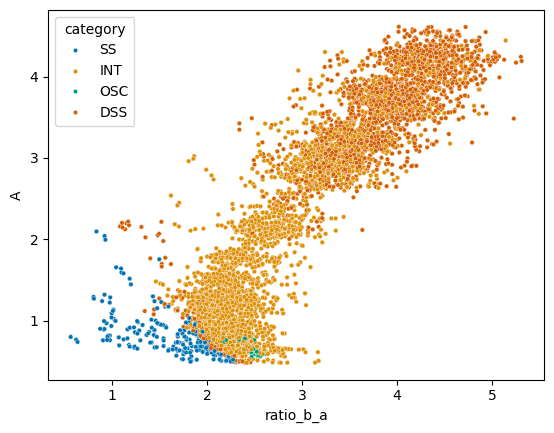

In [ ]:
colorblind_palette = sns.color_palette("colorblind")

# Define a fixed hue mapping
categories = ["SS", "INT", "OSC", "DSS"]
hue_mapping = {cat: colorblind_palette[i] for i, cat in enumerate(categories)}

sns.scatterplot(df, x="ratio_b_a", y="A", hue="category", palette=hue_mapping, hue_order=categories, marker="o", s=10)
